## Section 1

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------

### 1. Load dataset

# --------------------

In [288]:
df = pd.read_csv("dataset_2019_2022.csv")

In [289]:
print("Original dataset shape:", df.shape)

Original dataset shape: (77750, 12)


In [290]:
# -----------------------------------

In [291]:
# Checking the data types

In [292]:
# -----------------------------------

In [293]:
print("\nOriginal column data types:")
print(df.dtypes)


Original column data types:
customer_id           int64
product_id            int64
basket_id             int64
loyalty              object
household_type       object
age_band             object
department           object
brand                object
commodity            object
store                 int64
price               float64
transaction_date     object
dtype: object


In [294]:
# -----------------------------------

In [295]:
# Checking MISSING / NULL VALUES

In [296]:
# -----------------------------------

In [297]:
print("\nMissing values before handling:")
print(df.isnull().sum())


Missing values before handling:
customer_id         0
product_id          0
basket_id           0
loyalty             0
household_type      0
age_band            0
department          0
brand               0
commodity           0
store               0
price               0
transaction_date    0
dtype: int64


In [298]:
# -----------------------------------

In [299]:
# Check if any customer_id contains 'Customer'

In [300]:
# -----------------------------------

In [301]:
df["customer_id"].astype(str).str.contains("Customer").sum()

np.int64(0)

In [302]:
# -----------------------------------

In [303]:
# Check if standardisation is needed

In [304]:
# -----------------------------------

In [305]:
# Based on below output, only "loyalty" needs standardisation.

In [306]:
print("Unique loyalty values before cleaning:")
print(df["loyalty"].unique())

Unique loyalty values before cleaning:
['Loyalist' 'Promiscuous' 'First Time Buyer']


In [307]:
print("Unique household type values before cleaning:")
print(df["household_type"].unique())


Unique household type values before cleaning:
['1 adult with kids' 'Single female' '2 adults with no kids'
 '2 adults with kids' 'Single male']


In [308]:
print("Unique Age Band values before cleaning:")
print("Age Band:", df["age_band"].unique())

Unique Age Band values before cleaning:
Age Band: ['19-24' '25-34' '35-44' '45-54' 'Greater than 65' '55-64']


# --------------------

### 2. Data Cleaning

# --------------------

In [309]:
# -----------------------------------

In [310]:
# 1. Convert transaction_date column to datetime

In [311]:
# -----------------------------------

In [312]:
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    dayfirst=True,
    errors="coerce"
)

In [313]:
print("\nData types after conversion:")
print(df.dtypes)


Data types after conversion:
customer_id                  int64
product_id                   int64
basket_id                    int64
loyalty                     object
household_type              object
age_band                    object
department                  object
brand                       object
commodity                   object
store                        int64
price                      float64
transaction_date    datetime64[ns]
dtype: object


In [314]:
# -----------------------------------

In [315]:
# 2. STANDARDISE DATE FORMAT

In [316]:
# -----------------------------------

In [317]:
df["year"] = df["transaction_date"].dt.year

In [318]:
df["month"] = df["transaction_date"].dt.month

In [319]:
# The dataset confirms that 2022 contains only 5 months of data, validating that it is incomplete.

In [320]:
months_per_year = df.groupby("year")["month"].nunique()
print(months_per_year)

year
2019    12
2020    12
2021    12
2022     5
Name: month, dtype: int64


In [321]:
# -----------------------------------

In [322]:
# 3. REMOVE DUPLICATE RECORDS

In [323]:
# -----------------------------------

In [324]:
# Remove Duplicates

In [325]:
duplicates_before = df.duplicated().sum()
print("\nDuplicate rows before removal:", duplicates_before)



Duplicate rows before removal: 59


In [326]:
df_cleaned = df.drop_duplicates().copy()

In [327]:
duplicates_after = df_cleaned.duplicated().sum()
print("Duplicate rows after removal:", duplicates_after)

Duplicate rows after removal: 0


In [328]:
print("After duplicate records removed dataset shape:", df_cleaned.shape)

After duplicate records removed dataset shape: (77691, 14)


In [329]:
# -----------------------------------

In [330]:
# SAVE CLEANED FILE AS NEW FILE

In [331]:
# -----------------------------------

In [332]:
df_cleaned.to_csv("dataset_2019_2022_cleaned.csv", index=False)

In [333]:
print("\nCleaned dataset saved as: dataset_2019_2022_cleaned.csv")


Cleaned dataset saved as: dataset_2019_2022_cleaned.csv


In [334]:
# -----------------------------------

In [335]:
# 4. STANDARDISE CATEGORICAL VALUES

In [336]:
# -----------------------------------

In [337]:
if "loyalty" in df_cleaned.columns:
    df_cleaned["loyalty"] = df_cleaned["loyalty"].replace({
        "Promiscuous": "Non-Loyalist",
        "First Time Buyer": "First-time",
        "First-time buyer": "First-time",
        "Loyal": "Loyalist"
    })

In [338]:
print("\nUnique loyalty values after standardisation:")
print(df_cleaned["loyalty"].unique())


Unique loyalty values after standardisation:
['Loyalist' 'Non-Loyalist' 'First-time']


In [339]:
df_cleaned.to_csv("dataset_2019_2022_cleaned.csv", index=False)
print("\nCleaned dataset saved as: dataset_2019_2022_cleaned.csv")


Cleaned dataset saved as: dataset_2019_2022_cleaned.csv


In [340]:
# -----------------------------------

In [341]:
# 5. Convert to Category Type

In [342]:
# -----------------------------------

In [343]:
categorical_cols = [
    "loyalty", "household_type", "age_band",
    "department", "brand", "commodity"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

In [344]:
print("\nData types after conversion:")
print(df.dtypes)


Data types after conversion:
customer_id                  int64
product_id                   int64
basket_id                    int64
loyalty                   category
household_type            category
age_band                  category
department                category
brand                     category
commodity                 category
store                        int64
price                      float64
transaction_date    datetime64[ns]
year                         int32
month                        int32
dtype: object


In [345]:
# -----------------------------------

In [346]:
# 5. DATA VALIDATION

In [347]:
# -----------------------------------

In [348]:
print("\nFinal dataset shape:", df_cleaned.shape)


Final dataset shape: (77691, 14)


In [349]:
print("\nSummary statistics:")
print(df_cleaned.describe(include="all"))


Summary statistics:
         customer_id    product_id     basket_id       loyalty  \
count   7.769100e+04  7.769100e+04  7.769100e+04         77691   
unique           NaN           NaN           NaN             3   
top              NaN           NaN           NaN  Non-Loyalist   
freq             NaN           NaN           NaN         44902   
mean    2.425174e+04  3.579784e+06  6.905136e+04           NaN   
min     1.580300e+04  3.508200e+04  5.196400e+04           NaN   
25%     1.952550e+04  9.201090e+05  5.987200e+04           NaN   
50%     2.342900e+04  1.037863e+06  6.802100e+04           NaN   
75%     2.699300e+04  5.578437e+06  7.521500e+04           NaN   
max     2.811700e+06  1.820392e+07  6.811600e+06           NaN   
std     3.966980e+04  4.715086e+06  1.056146e+05           NaN   

            household_type age_band department     brand commodity    store  \
count                77691    77691      77691     77691     77691  77691.0   
unique                   5  

In [350]:
print("\nPreview of cleaned dataset:")
print(df_cleaned.head())


Preview of cleaned dataset:
   customer_id  product_id  basket_id   loyalty     household_type age_band  \
0        15803     1131974      57266  Loyalist  1 adult with kids    19-24   
1        15803     1051516      57266  Loyalist  1 adult with kids    19-24   
2        15803      967254      57266  Loyalist  1 adult with kids    19-24   
3        15803     1134222      57266  Loyalist  1 adult with kids    19-24   
4        15803     1003421      57266  Loyalist  1 adult with kids    19-24   

       department     brand                commodity  store  price  \
0         Grocery   private   Baked bread/buns/rolls    374   0.99   
1         Produce  national  Vegetables - all others    374   0.70   
2  Pharmaceutical  national             Cold and flu    374   1.68   
3         Grocery   private         Paper housewares    374   2.59   
4         Grocery  national                     Soup    374   0.60   

  transaction_date  year  month  
0       2020-10-05  2020     10  
1      

In [351]:
categorical_cols = [
    "loyalty", "household_type", "age_band",
    "department", "brand", "commodity"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

--------------------

## Section 2 - Visualization

#### 1. Customer Loyalty Impact on Revenue Growth

In [352]:
annual_loyalty_revenue = (
    df_cleaned.groupby(["year", "loyalty"])["price"]
      .sum()
      .unstack()
)

In [353]:
# keep years in order

In [354]:
annual_loyalty_revenue = annual_loyalty_revenue.sort_index()

In [355]:
# arrange loyalty order to match your chart

In [356]:
desired_order = ["First-time", "Loyalist", "Non-Loyalist"]

In [357]:
# Keep only columns that exist in dataset

In [358]:
existing_order = [col for col in desired_order if col in annual_loyalty_revenue.columns]
annual_loyalty_revenue = annual_loyalty_revenue[existing_order]

In [359]:
# -----------------------------

In [360]:
# 5. Plot grouped bar chart

In [361]:
# -----------------------------

In [362]:
print(annual_loyalty_revenue.columns)

Index(['First-time', 'Loyalist', 'Non-Loyalist'], dtype='object', name='loyalty')


In [363]:
print(plt.style.available)
plt.style.use('seaborn-v0_8-notebook')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


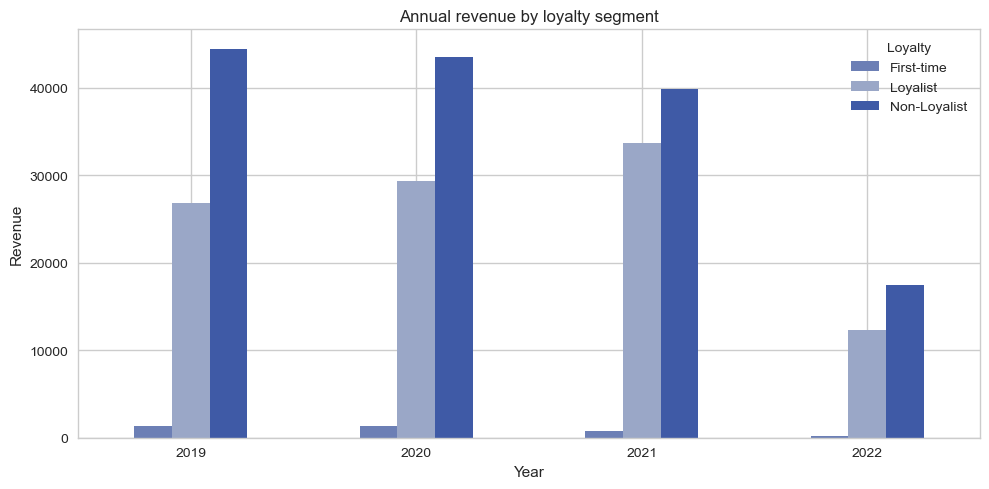

In [364]:
ax = annual_loyalty_revenue.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.5,
    color=["#6C7FB5", "#9AA7C7", "#3F5AA6"]
)
ax.set_title("Annual revenue by loyalty segment")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue")
ax.legend(title="Loyalty")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 2. Revenue by Product Category (Department)

In [365]:
# Step 1: Calculate revenue by department

In [366]:
dept_revenue = df_cleaned.groupby("department")["price"].sum().sort_values()

In [367]:
# Step 2: Create custom colors (highlight Grocery)

In [368]:
colors = ["#3F5AA6" if dept == "Grocery" else "#9AA7C7" for dept in dept_revenue.index]

In [369]:
# Step 3: Plot chart

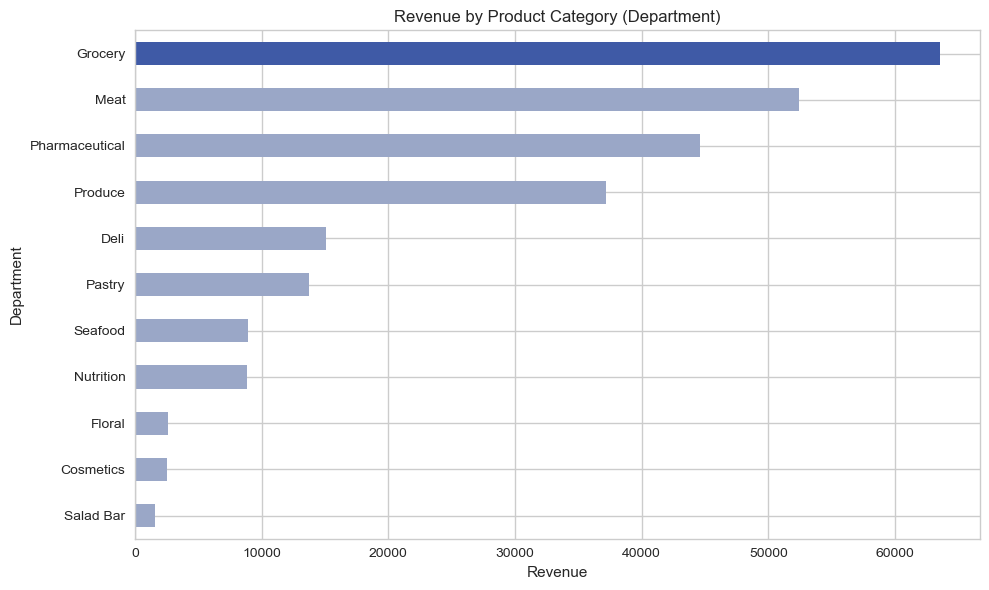

In [370]:
ax = dept_revenue.plot(
    kind="barh",
    figsize=(10, 6),
    color=colors
)
ax.set_title("Revenue by Product Category (Department)")
ax.set_xlabel("Revenue")
ax.set_ylabel("Department")

plt.tight_layout()
plt.show()

#### 3. Loyalist Customer Distribution by Age Band

In [371]:
# Filter Loyalist customers

In [372]:
loyalists = df_cleaned[df_cleaned["loyalty"] == "Loyalist"]

In [373]:
# Count Loyalists by age band

In [374]:
age_counts = loyalists["age_band"].value_counts()

In [375]:
# Reorder age bands (optional but good for consistency)

In [376]:
age_order = ["19-24", "25-34", "35-44", "45-54", "55-64", "Greater than 65"]
age_counts = age_counts.reindex(age_order, fill_value=0)

In [377]:
# Colors (same theme)

In [378]:
colors = ["#A9C2D0", "#3E7BA7", "#A8C98B", "#4B9C3A", "#D79A8E", "#C9B39B"]

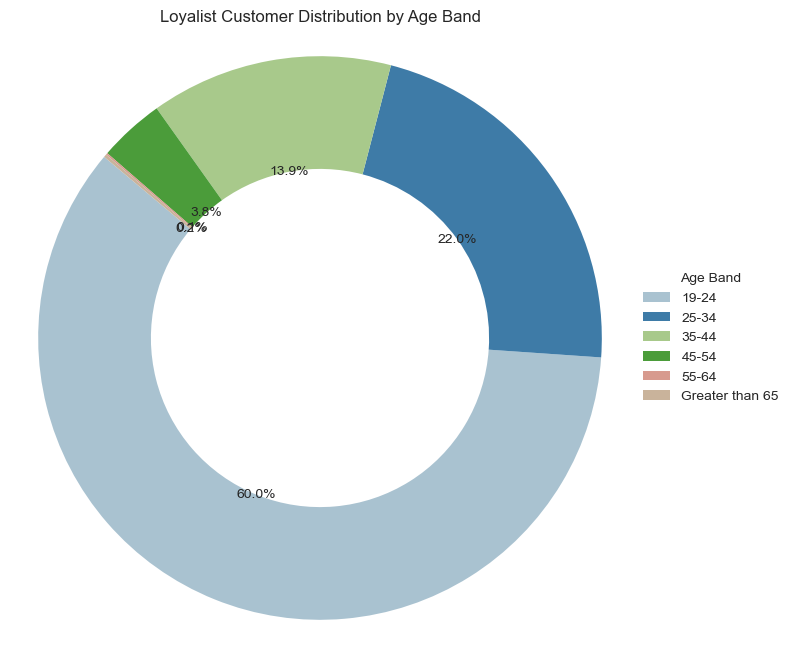

In [379]:
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    age_counts,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"width": 0.4}
)

plt.legend(
    wedges,
    age_counts.index,
    title="Age Band",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Loyalist Customer Distribution by Age Band")

plt.axis("equal")
plt.show()

#### 4. First-Time Buyer basket value by age band

In [380]:
# Filter First-time customers

In [381]:
print("Unique loyalty values:", df_cleaned["loyalty"].unique())


Unique loyalty values: ['Loyalist' 'Non-Loyalist' 'First-time']


In [382]:
first_time = df_cleaned[df_cleaned["loyalty"] == "First-time"]

In [383]:
# Calculate total basket value (sum of price) by age band

In [384]:
age_values = first_time.groupby("age_band", observed=True)["price"].sum()

In [385]:
# Reorder age bands

In [386]:
age_order = ["19-24", "25-34", "35-44", "45-54", "55-64", "Greater than 65"]
age_values = age_values.reindex(age_order, fill_value=0)

In [387]:
colors = ["#D77A87", "#A89A47", "#4CA27E", "#5FA3B3", "#BFA3D1", "#C9B39B"]

C:\Users\himas\AppData\Local\Temp\ipykernel_13356\3790459600.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[1, 0, 0.85, 1])


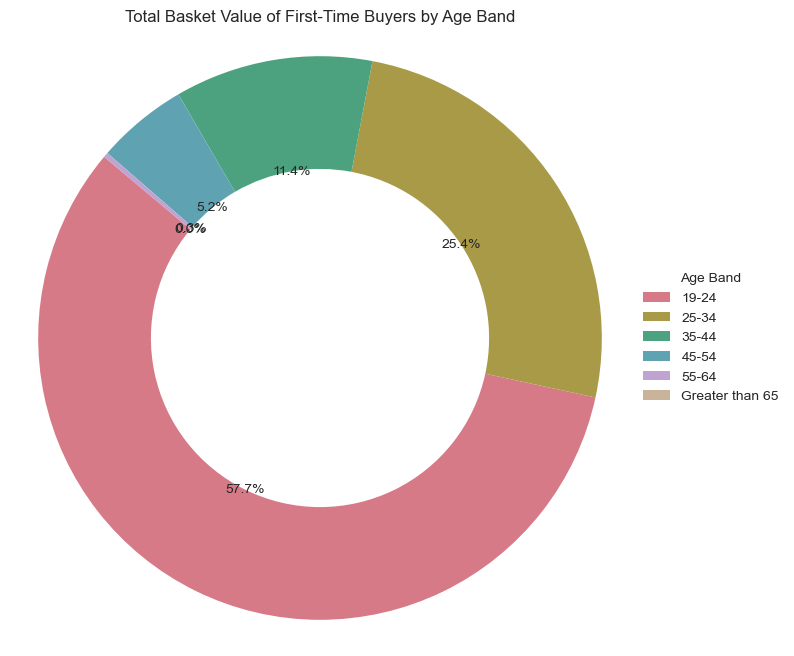

In [388]:
if age_values.sum() == 0:
    print("No data available for pie chart")
else:
    # Create donut chart
    plt.figure(figsize=(8, 8))

    wedges, texts, autotexts = plt.pie(
        age_values,
        autopct="%1.1f%%",
        startangle=140,
        colors=colors,
        wedgeprops={"width": 0.4}
    )

    plt.legend(
        wedges,
        age_values.index,
        title="Age Band",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.title("Total Basket Value of First-Time Buyers by Age Band")
    plt.axis("equal")
    plt.tight_layout(rect=[1, 0, 0.85, 1])

    plt.show()

#### 5. Monthly Revenue Forecast (Loyalists + 5% Growth)

In [389]:
# Make a safe copy

In [390]:
df = df_cleaned.copy()

In [391]:
# Create monthly revenue

In [392]:
loyalists["year_month"] = loyalists["transaction_date"].dt.to_period("M")
monthly_revenue = (
    loyalists.groupby("year_month", observed=True)["price"]
    .sum()
    .reset_index()
)

C:\Users\himas\AppData\Local\Temp\ipykernel_13356\4099904250.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loyalists["year_month"] = loyalists["transaction_date"].dt.to_period("M")


In [393]:
# Convert Period to timestamp

In [394]:
monthly_revenue["year_month"] = monthly_revenue["year_month"].dt.to_timestamp()

In [395]:
# Use the last 12 months as the forecast base

In [396]:
# Sort by date

In [397]:
monthly_revenue = monthly_revenue.sort_values("year_month").reset_index(drop=True)

In [398]:
# Keep only the last 12 months of actual data as the seasonal pattern

In [399]:
last_12 = monthly_revenue.tail(12).copy()

In [400]:
# Start forecast from the month after the last actual month

In [401]:
last_date = monthly_revenue["year_month"].max()

In [402]:
# Create next 24 monthly dates

In [403]:
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=24,
    freq="MS"   
)

In [404]:
# Repeat the last 12-month revenue pattern for the next 24 months

In [405]:
base_pattern = list(last_12["price"].values)
forecast_values = (base_pattern * 2)[:24]

In [406]:
# Create forecast DataFrame

In [407]:
forecast_df = pd.DataFrame({
    "year_month": future_dates,
    "forecast": forecast_values
})

In [408]:
# Add 5% growth scenario

In [409]:
forecast_df["forecast_5_percent"] = forecast_df["forecast"] * 1.05

In [410]:
# Plot forecast chart

In [411]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [412]:
# Plot baseline forecast

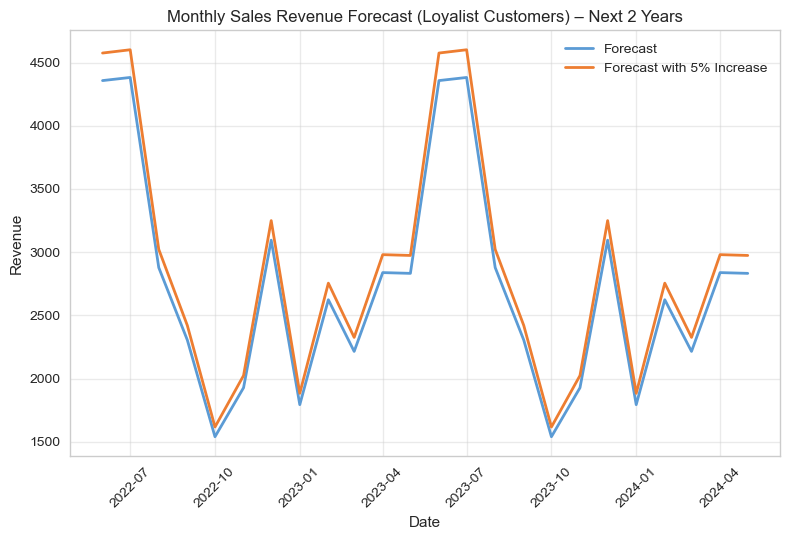

In [413]:
plt.plot(
    forecast_df["year_month"],
    forecast_df["forecast"],
    label="Forecast",
    color="#5B9BD5",
    linewidth=2
)
plt.plot(
    forecast_df["year_month"],
    forecast_df["forecast_5_percent"],
    label="Forecast with 5% Increase",
    color="#ED7D31",
    linewidth=2
)
# Title and labels
plt.title("Monthly Sales Revenue Forecast (Loyalist Customers) – Next 2 Years")
plt.xlabel("Date")
plt.ylabel("Revenue")

# Grid and legend
plt.grid(True, axis="both", linestyle="-", alpha=0.4)
plt.legend()

# Rotate dates
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
